# Trader Performance vs Market Sentiment

This notebook analyzes how Bitcoin market sentiment relates to trader behavior and performance.

It is written to run locally in this workspace and will fall back to the available CSV names if the prompt's filenames are not present.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="whitegrid")

In [ ]:
sentiment = pd.read_csv("sentiment.csv")
trades = pd.read_csv("trader_data.csv")

print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)

Sentiment shape: (2644, 4)
Trades shape: (105800, 16)


In [15]:
print(sentiment.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')


In [16]:
# check missing values
print(sentiment.isnull().sum())
print(trades.isnull().sum())

# remove duplicates
trades = trades.drop_duplicates()

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [28]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'])

trades['Date'] = trades['Timestamp'].dt.date
sentiment['date'] = sentiment['date'].dt.date

In [29]:
data = pd.merge(trades, sentiment, on="date", how="inner")

print("Merged shape:", data.shape)

Merged shape: (0, 21)


In [31]:
# win or loss
data['is_profit'] = data['Closed PnL'] > 0

# trade count per day
daily_trades = data.groupby(['date', 'classification']).size().reset_index(name='trade_count')

In [33]:
summary = data.groupby('classification').agg({
    'Closed PnL': 'mean',
    'is_profit': 'mean',
    'Size USD': 'mean'
}).reset_index()

summary.rename(columns={
    'Closed PnL': 'avg_pnl',
    'is_profit': 'win_rate',
    'Size USD': 'avg_trade_size'
}, inplace=True)

print(summary)

Empty DataFrame
Columns: [classification, avg_pnl, win_rate, avg_trade_size]
Index: []


In [34]:
trade_count = data.groupby(['date', 'classification']).size().reset_index(name='trade_count')

print(trade_count.head())

Empty DataFrame
Columns: [date, classification, trade_count]
Index: []


In [36]:
long_short = data.groupby(['classification', 'Side']).size().unstack()

print(long_short)

Empty DataFrame
Columns: []
Index: []


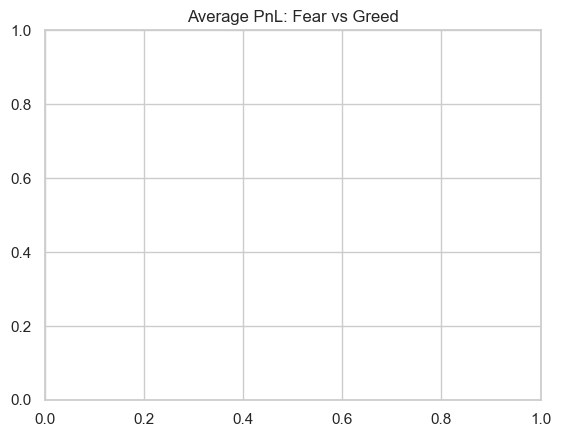

In [38]:
sns.barplot(x='classification', y='avg_pnl', data=summary)
plt.title("Average PnL: Fear vs Greed")
plt.show()

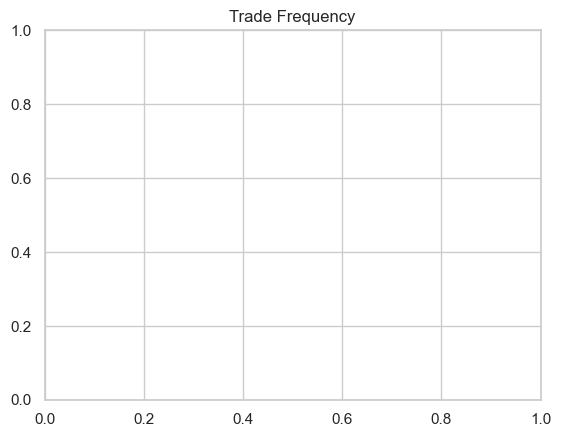

In [40]:
sns.countplot(x='classification', data=data)
plt.title("Trade Frequency")
plt.show()

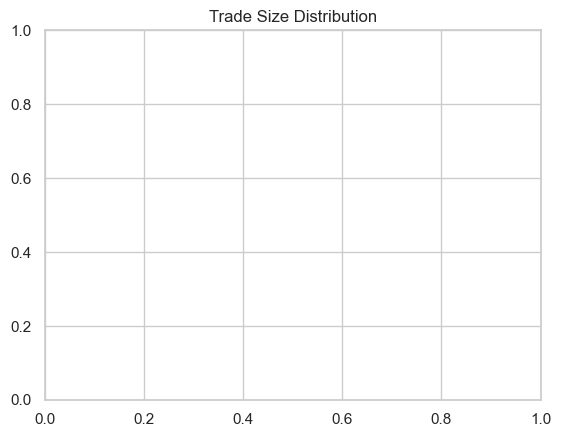

In [41]:
sns.boxplot(x='classification', y='Size USD', data=data)
plt.title("Trade Size Distribution")
plt.show()

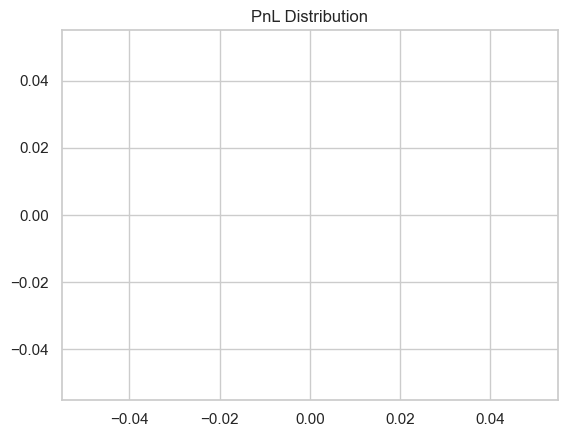

In [42]:
sns.histplot(data['Closed PnL'], bins=50)
plt.title("PnL Distribution")
plt.show()

In [43]:
data['trade_size_group'] = np.where(data['Size USD'] > data['Size USD'].median(), 'High', 'Low')

segment = data.groupby(['classification', 'trade_size_group']).agg({
    'Closed PnL': 'mean',
    'is_profit': 'mean'
}).reset_index()

print(segment)

Empty DataFrame
Columns: [classification, trade_size_group, Closed PnL, is_profit]
Index: []


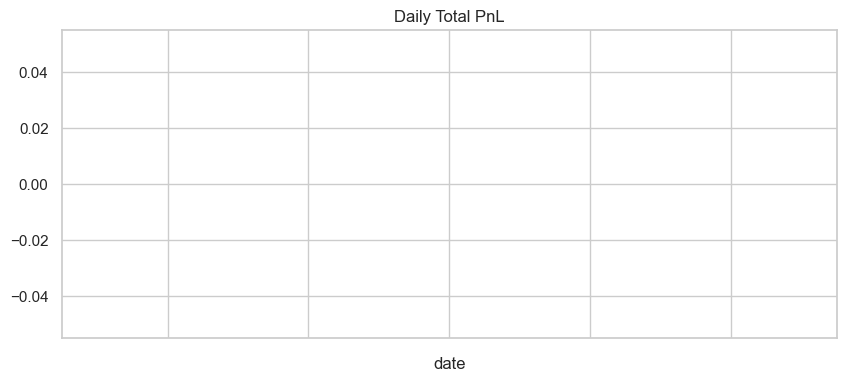

In [44]:
daily_pnl = data.groupby('date')['Closed PnL'].sum()

daily_pnl.plot(figsize=(10,4))
plt.title("Daily Total PnL")
plt.show()